# K-Means Algorithm

#### K-Means is an unsupervised machine learning algorithm used for clustering data into distinct groups. It automatically identifies patterns in the data without predefined labels, organizing data points into K clusters based on their similarities. This makes it useful for discovering hidden structures in large datasets.

In [2]:
# import the libs

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import warnings

warnings.filterwarnings("ignore")

In [24]:
data = pd.read_csv("wholesale.csv")
data.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergent,Delicassen
0,1,3,9989,9996,7915,4196,3476,2961
1,2,3,11692,3731,12817,3499,2459,4973
2,1,2,14990,11965,12921,3652,2885,4433
3,1,3,8873,9154,11789,1198,3419,3777
4,1,2,7675,10762,4693,2660,5236,2869


In [25]:
#  stats of the data

data.describe()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergent,Delicassen
count,40.00000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000
mean,1.50000,2.125000,10164.775000,6603.150000,7954.400000,2833.175000,3388.800000,2921.525000
std,0.50637,0.757442,4896.987999,3071.616175,3235.754941,1301.489204,1475.707326,1596.691917
min,1.00000,1.000000,2161.000000,1206.000000,2663.000000,646.000000,598.000000,16.000000
25%,1.00000,2.000000,7017.750000,4065.250000,5511.750000,1813.500000,2275.500000,1279.500000
50%,1.50000,2.000000,9809.000000,7196.500000,7728.000000,2919.000000,3542.000000,3177.000000
75%,2.00000,3.000000,14305.250000,8755.250000,11044.250000,3803.250000,4568.250000,4493.750000
max,2.00000,3.000000,19262.000000,11965.000000,12921.000000,4996.000000,5923.000000,4973.000000


In [26]:
# Standardizing the data

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

data_scaled = scaler.fit_transform(data)

pd.DataFrame(data_scaled).describe()

,0,1,2,3,4,5,6,7
count,40.000000,4.000000e+01,4.000000e+01,4.000000e+01,4.000000e+01,4.000000e+01,4.000000e+01,4.000000e+01
mean,0.000000,5.551115e-17,9.436896e-17,9.992007e-17,1.110223e-16,-1.332268e-16,-9.992007e-17,-4.163336e-17
std,1.012739,1.012739e+00,1.012739e+00,1.012739e+00,1.012739e+00,1.012739e+00,1.012739e+00,1.012739e+00
min,-1.000000,-1.504184e+00,-1.655250e+00,-1.779489e+00,-1.656123e+00,-1.701926e+00,-1.915253e+00,-1.842898e+00
25%,-1.000000,-1.671316e-01,-6.508319e-01,-8.367684e-01,-7.645102e-01,-7.934488e-01,-7.640287e-01,-1.041493e+00
50%,0.000000,-1.671316e-01,-7.357734e-02,1.956328e-01,-7.085957e-02,6.678377e-02,1.051372e-01,1.620410e-01
75%,1.000000,1.169921e+00,8.562860e-01,7.095666e-01,9.670735e-01,7.548531e-01,8.094257e-01,9.972207e-01
max,1.000000,1.169921e+00,1.881385e+00,1.767850e+00,1.554466e+00,1.682978e+00,1.739155e+00,1.301196e+00


In [27]:
help(KMeans)

Help on class KMeans in module sklearn.cluster._kmeans:

class KMeans(_BaseKMeans)
 |  KMeans(
 |      n_clusters=8,
 |      *,
 |      init='k-means++',
 |      n_init='auto',
 |      max_iter=300,
 |      tol=0.0001,
 |      verbose=0,
 |      random_state=None,
 |      copy_x=True,
 |      algorithm='lloyd'
 |  )
 |
 |  K-Means clustering.
 |
 |  Read more in the :ref:`User Guide <k_means>`.
 |
 |  Parameters
 |  ----------
 |
 |  n_clusters : int, default=8
 |      The number of clusters to form as well as the number of
 |      centroids to generate.
 |
 |      For an example of how to choose an optimal value for `n_clusters` refer to
 |      :ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.
 |
 |  init : {'k-means++', 'random'}, callable or array-like of shape             (n_clusters, n_features), default='k-means++'
 |      Method for initialization:
 |
 |      * 'k-means++' : selects initial cluster centroids using sampling             based on an empiric

In [30]:
kmeans = KMeans(n_clusters = 2, init = "k-means++")

kmeans.fit(data_scaled)

kmeans.inertia_

266.81230299758704

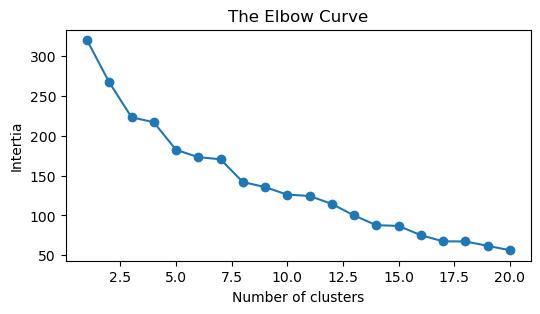

In [31]:
wcss = []

for cluster in range (1,21):
    kmeans = KMeans(n_clusters = cluster, init = "k-means++")
    kmeans.fit(data_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(6,3))
plt.plot(range(1,21), wcss, marker = "o")
plt.title("The Elbow Curve")
plt.xlabel("Number of clusters")
plt.ylabel("Intertia")
plt.show()

In [34]:
# Build the model with the 7 clusters

kmeans = KMeans(n_clusters = 8, init = "k-means++")
kmeans.fit(data_scaled)
pred = kmeans.predict(data_scaled)

df = pd.DataFrame(data_scaled)
df.head()

,0,1,2,3,4,5,6,7
0,-1.0,1.169921,-0.036352,1.118653,-0.012332,1.060467,0.059843,0.025038
1,1.0,1.169921,0.315843,-0.946974,1.521916,0.518104,-0.638097,1.301196
2,-1.0,-0.167132,0.997898,1.767850,1.554466,0.637160,-0.345745,0.958689
3,-1.0,1.169921,-0.267150,0.841038,1.200168,-1.272393,0.020725,0.542605
4,-1.0,-0.167132,-0.514907,1.371210,-1.020766,-0.134754,1.267685,-0.033315


In [35]:
df["cluster"] = pred
df.head()

,0,1,2,3,4,5,6,7,cluster
0,-1.0,1.169921,-0.036352,1.118653,-0.012332,1.060467,0.059843,0.025038,0
1,1.0,1.169921,0.315843,-0.946974,1.521916,0.518104,-0.638097,1.301196,5
2,-1.0,-0.167132,0.997898,1.767850,1.554466,0.637160,-0.345745,0.958689,0
3,-1.0,1.169921,-0.267150,0.841038,1.200168,-1.272393,0.020725,0.542605,6
4,-1.0,-0.167132,-0.514907,1.371210,-1.020766,-0.134754,1.267685,-0.033315,0


In [36]:
df.tail()

,0,1,2,3,4,5,6,7,cluster
35,-1.0,-0.167132,1.013822,-0.318878,-1.459569,0.689295,-1.808881,-1.336113,4
36,1.0,-0.167132,1.468388,-1.498247,-0.742836,0.449628,0.201902,1.162290,3
37,-1.0,-0.167132,-1.181038,0.351091,0.500649,-0.466241,-0.227706,1.091252,6
38,-1.0,-0.167132,0.759448,1.421326,0.414892,-0.381424,-1.915253,0.125887,0
39,-1.0,-0.167132,1.214840,-0.806518,-1.351590,-1.435802,-0.472705,-1.842898,4


In [37]:
df.head(20)

,0,1,2,3,4,5,6,7,cluster
0,-1.0,1.169921,-0.036352,1.118653,-0.012332,1.060467,0.059843,0.025038,0
1,1.0,1.169921,0.315843,-0.946974,1.521916,0.518104,-0.638097,1.301196,5
2,-1.0,-0.167132,0.997898,1.767850,1.554466,0.637160,-0.345745,0.958689,0
3,-1.0,1.169921,-0.267150,0.841038,1.200168,-1.272393,0.020725,0.542605,6
4,-1.0,-0.167132,-0.514907,1.371210,-1.020766,-0.134754,1.267685,-0.033315,0
5,1.0,-0.167132,-1.655250,-0.180400,-0.728439,1.372501,-0.745842,0.198195,1
6,-1.0,1.169921,-0.799889,0.826531,1.126930,-1.151004,0.804450,0.551485,6
7,-1.0,-0.167132,-1.482771,1.740484,1.320354,0.887720,0.329549,-1.246680,0
8,-1.0,1.169921,0.696785,-0.581326,-0.157869,-0.487251,-1.802704,0.726544,6
9,1.0,1.169921,-0.110803,-1.508468,-1.343139,0.345357,-1.554959,-1.751562,1


In [38]:
df["cluster"].value_counts()

cluster
0    8
1    8
6    6
3    6
7    4
4    4
5    2
2    2
Name: count, dtype: int64

In [39]:
# Function to take input, standardize it, and predict the cluster
def get_cluster_prediction():
    # Collection user input for each features
    Channel = int(input("Enter Channel (e.g., 1,2): "))
    Region = int(input("Enter Region (e.g., 1,2,3): "))
    Fresh= int(input("Enter annual spending on Fresh products: "))
    Milk = float(input("Enter annual spending on Milk: "))
    Grocery = float(input("Enter annual spending on Grocery: "))
    Frozen = float(input("Enter annual spending on Frozen products: "))
    Detergents_Paper = float(input("Enter annual spending on Detergents_Paper: "))
    Delicassen = float(input("Enter annual spending on Delicassen: " ))

    # Create a data point with the input values
    user_data = np.array([[Channel, Region, Fresh, Milk, Grocery, Frozen, Detergents_Paper, Delicassen]])

    # Standardize the user input using the already fitted scaler
    user_data_scaled = scaler.transform(user_data)

    # Predict the cluster using the clustering model
    cluster = kmeans.predict(user_data_scaled)

    # Output the predicted cluster
    print(f"The customer belongs to cluster: {cluster[0]}")
    

In [40]:
get_cluster_prediction()

Enter Channel (e.g., 1,2):  1
Enter Region (e.g., 1,2,3):  3
Enter annual spending on Fresh products:  24546
Enter annual spending on Milk:  9000
Enter annual spending on Grocery:  2500
Enter annual spending on Frozen products:  522
Enter annual spending on Detergents_Paper:  250
Enter annual spending on Delicassen:  250


The customer belongs to cluster: 4
